# Level 4 — Feature-Based DQN Baseline

Level 4 replaces the tabular state with a pixel-only observation. This notebook implements the first Level 4 agent:

## Feature-based DQN

The agent receives the RGB frame and extracts approximate coordinates for:

- the left paddle,
- the right paddle,
- the ball.

To represent motion, the network also receives the change in these coordinates from the previous frame. The resulting 12-dimensional vector is processed by a multilayer perceptron.

This notebook intentionally excludes actor-critic methods and CNN-DQN for now. CNN-DQN will be implemented only after this baseline is confirmed to train correctly.

### Controlled settings

- 2000 training episodes
- first 400 episodes use fully random actions
- original environment reward
- replay buffer
- target network
- Huber loss
- gradient clipping
- separate training and evaluation seeds
- no anti-chattering or reward shaping


In [1]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.11.0+cu128
12.8
True
1


In [2]:
import sys
print(sys.executable)

c:\Users\MANAN\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
import torch
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 5050 Laptop GPU


## Imports


In [4]:
from pathlib import Path
import sys
from typing import Any, Dict, Optional
from collections import Counter, deque
import random
import time

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "paddle_duel_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from paddle_duel_env import (
    PaddleDuelEnv,
    BaseAgent,
    RandomAgent,
    TrackingAgent,
    ACTION_UP,
    ACTION_DOWN,
    ACTION_STAY,
    ACTION_NAMES,
    extract_simple_pixel_features,
    record_episode,
    animate_episode,
    show_frame,
)

torch.set_num_threads(1)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


## Inspect the Level 4 pixel observation

The observation is an RGB image. The helper `extract_simple_pixel_features` detects colored regions corresponding to the paddles and ball.


Observation type: <class 'numpy.ndarray'>
Observation shape: (150, 320, 3)
Observation dtype: uint8
Pixel range: 8 to 255

Extracted features:
[0.07685    0.5        0.9263798  0.5        0.5015674  0.60402685]
Feature dimension: 6


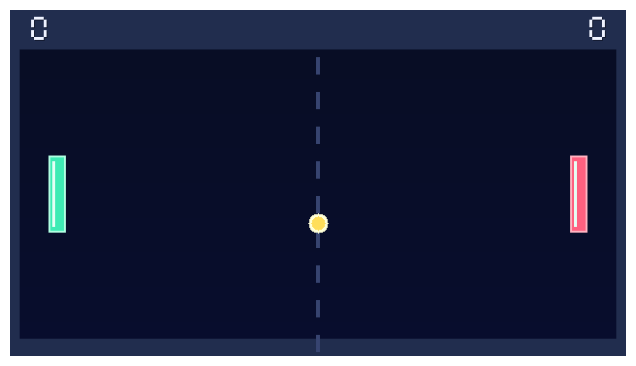

In [8]:
inspection_env = PaddleDuelEnv(
    level=4,
    opponent="weak",
    max_seconds=6,
    render_scale=2,
)

sample_frame, sample_info = inspection_env.reset(seed=0)

print("Observation type:", type(sample_frame))
print("Observation shape:", sample_frame.shape)
print("Observation dtype:", sample_frame.dtype)
print("Pixel range:", sample_frame.min(), "to", sample_frame.max())

sample_features = extract_simple_pixel_features(sample_frame)

print("\nExtracted features:")
print(sample_features)
print("Feature dimension:", len(sample_features))

show_frame(inspection_env)


## Feature representation

The helper returns six normalized coordinates:

```text
[left_x, left_y, right_x, right_y, ball_x, ball_y]
```

One image alone does not explicitly reveal the ball direction. Therefore, we concatenate the current coordinates with their frame-to-frame difference:

```text
[current coordinates, coordinate differences]
```

This produces 12 inputs while still relying only on pixels.


In [10]:
FEATURE_NAMES = [
    "left_x",
    "left_y",
    "right_x",
    "right_y",
    "ball_x",
    "ball_y",
    "delta_left_x",
    "delta_left_y",
    "delta_right_x",
    "delta_right_y",
    "delta_ball_x",
    "delta_ball_y",
]


def build_feature_state(
    frame: np.ndarray,
    previous_coordinates: Optional[np.ndarray] = None,
):
    current_coordinates = extract_simple_pixel_features(frame).astype(
        np.float32
    )

    if previous_coordinates is None:
        coordinate_difference = np.zeros_like(
            current_coordinates,
            dtype=np.float32,
        )
    else:
        coordinate_difference = (
            current_coordinates - previous_coordinates
        ).astype(np.float32)

    state_vector = np.concatenate(
        [current_coordinates, coordinate_difference]
    ).astype(np.float32)

    return state_vector, current_coordinates


feature_state, coordinates = build_feature_state(sample_frame)

for name, value in zip(FEATURE_NAMES, feature_state):
    print(f"{name:18s}: {value:.4f}")

FEATURE_DIM = len(feature_state)
N_ACTIONS = 3

print("\nFeature dimension:", FEATURE_DIM)


left_x            : 0.0769
left_y            : 0.5000
right_x           : 0.9264
right_y           : 0.5000
ball_x            : 0.5016
ball_y            : 0.6040
delta_left_x      : 0.0000
delta_left_y      : 0.0000
delta_right_x     : 0.0000
delta_right_y     : 0.0000
delta_ball_x      : 0.0000
delta_ball_y      : 0.0000

Feature dimension: 12


## Replay buffer


In [11]:
class ReplayBuffer:
    def __init__(self, capacity: int = 50_000, seed: int = 0):
        if capacity <= 0:
            raise ValueError("capacity must be positive.")

        self.buffer = deque(maxlen=capacity)
        self.rng = random.Random(seed)

    def push(
        self,
        state,
        action: int,
        reward: float,
        next_state,
        done: bool,
    ) -> None:
        self.buffer.append(
            (
                np.asarray(state, dtype=np.float32),
                int(action),
                float(reward),
                np.asarray(next_state, dtype=np.float32),
                bool(done),
            )
        )

    def sample(self, batch_size: int):
        if batch_size > len(self.buffer):
            raise ValueError(
                "Cannot sample more transitions than the buffer contains."
            )

        transitions = self.rng.sample(
            list(self.buffer),
            batch_size,
        )

        states, actions, rewards, next_states, dones = zip(
            *transitions
        )

        return (
            np.stack(states),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.stack(next_states),
            np.asarray(dones, dtype=np.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)


## Feature DQN network


In [12]:
class FeatureQNetwork(nn.Module):
    def __init__(
        self,
        input_dim: int = FEATURE_DIM,
        n_actions: int = N_ACTIONS,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.network(x)


test_network = FeatureQNetwork().to(DEVICE)
test_input = torch.zeros(
    (1, FEATURE_DIM),
    dtype=torch.float32,
    device=DEVICE,
)

print(test_network)
print("Test output shape:", test_network(test_input).shape)


FeatureQNetwork(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)
Test output shape: torch.Size([1, 3])


## Feature DQN agent


In [13]:
class FeatureDQNAgent(BaseAgent):
    def __init__(
        self,
        feature_dim: int = FEATURE_DIM,
        n_actions: int = N_ACTIONS,
        learning_rate: float = 1e-4,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.05,
        epsilon_decay: float = 0.9999,
        buffer_capacity: int = 50_000,
        batch_size: int = 64,
        min_buffer_size: int = 2_000,
        target_update_steps: int = 1_000,
        train_frequency: int = 4,
        name: str = "Feature DQN",
        seed: int = 0,
        device=DEVICE,
    ):
        self.name = name
        self.feature_dim = int(feature_dim)
        self.n_actions = int(n_actions)
        self.gamma = float(gamma)

        self.epsilon_start = float(epsilon_start)
        self.epsilon_min = float(epsilon_min)
        self.epsilon_decay = float(epsilon_decay)
        self.epsilon = float(epsilon_start)

        self.batch_size = int(batch_size)
        self.min_buffer_size = int(min_buffer_size)
        self.target_update_steps = int(target_update_steps)
        self.train_frequency = int(train_frequency)

        self.device = device
        self.rng = np.random.default_rng(seed)

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        self.policy_net = FeatureQNetwork(
            feature_dim,
            n_actions,
        ).to(self.device)

        self.target_net = FeatureQNetwork(
            feature_dim,
            n_actions,
        ).to(self.device)

        self.target_net.load_state_dict(
            self.policy_net.state_dict()
        )
        self.target_net.eval()

        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=learning_rate,
        )

        self.replay_buffer = ReplayBuffer(
            capacity=buffer_capacity,
            seed=seed,
        )

        self.environment_steps = 0
        self.optimization_steps = 0
        self.previous_coordinates = None

    def reset(self) -> None:
        self.previous_coordinates = None

    def reset_exploration(self) -> None:
        self.epsilon = self.epsilon_start

    def decay_exploration(self) -> None:
        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay,
        )

    def observation_to_state(self, observation):
        state, current_coordinates = build_feature_state(
            observation,
            self.previous_coordinates,
        )

        self.previous_coordinates = current_coordinates
        return state

    def select_action_from_state(
        self,
        state,
        training: bool = False,
        force_random: bool = False,
    ) -> int:
        if force_random:
            return int(self.rng.integers(self.n_actions))

        if training and self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))

        state_tensor = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(0)

        self.policy_net.eval()

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)

        if training:
            self.policy_net.train()

        return int(torch.argmax(q_values, dim=1).item())

    def select_action(
        self,
        observation,
        info: Optional[Dict[str, Any]] = None,
        training: bool = False,
    ) -> int:
        state = self.observation_to_state(observation)

        return self.select_action_from_state(
            state,
            training=training,
        )

    def store_transition(
        self,
        state,
        action,
        reward,
        next_state,
        done,
    ) -> None:
        self.replay_buffer.push(
            state,
            action,
            reward,
            next_state,
            done,
        )

    def optimize(self) -> Optional[float]:
        if len(self.replay_buffer) < self.min_buffer_size:
            return None

        if self.environment_steps % self.train_frequency != 0:
            return None

        (
            states,
            actions,
            rewards,
            next_states,
            dones,
        ) = self.replay_buffer.sample(self.batch_size)

        states_tensor = torch.as_tensor(
            states,
            dtype=torch.float32,
            device=self.device,
        )

        actions_tensor = torch.as_tensor(
            actions,
            dtype=torch.long,
            device=self.device,
        ).unsqueeze(1)

        rewards_tensor = torch.as_tensor(
            rewards,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(1)

        next_states_tensor = torch.as_tensor(
            next_states,
            dtype=torch.float32,
            device=self.device,
        )

        dones_tensor = torch.as_tensor(
            dones,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(1)

        current_q_values = self.policy_net(
            states_tensor
        ).gather(1, actions_tensor)

        with torch.no_grad():
            next_q_values = self.target_net(
                next_states_tensor
            ).max(dim=1, keepdim=True).values

            target_q_values = (
                rewards_tensor
                + self.gamma
                * (1.0 - dones_tensor)
                * next_q_values
            )

        loss = F.smooth_l1_loss(
            current_q_values,
            target_q_values,
        )

        self.optimizer.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            self.policy_net.parameters(),
            max_norm=10.0,
        )

        self.optimizer.step()

        self.optimization_steps += 1

        if (
            self.environment_steps
            % self.target_update_steps
            == 0
        ):
            self.target_net.load_state_dict(
                self.policy_net.state_dict()
            )

        return float(loss.item())

    def save(self, path) -> None:
        checkpoint = {
            "name": self.name,
            "feature_dim": self.feature_dim,
            "n_actions": self.n_actions,
            "gamma": self.gamma,
            "epsilon_start": self.epsilon_start,
            "epsilon_min": self.epsilon_min,
            "epsilon_decay": self.epsilon_decay,
            "epsilon": self.epsilon,
            "batch_size": self.batch_size,
            "min_buffer_size": self.min_buffer_size,
            "target_update_steps": self.target_update_steps,
            "train_frequency": self.train_frequency,
            "environment_steps": self.environment_steps,
            "optimization_steps": self.optimization_steps,
            "policy_state_dict": self.policy_net.state_dict(),
            "target_state_dict": self.target_net.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
        }

        torch.save(checkpoint, path)

    @classmethod
    def load(
        cls,
        path,
        seed: int = 0,
        device=DEVICE,
    ):
        checkpoint = torch.load(
            path,
            map_location=device,
        )

        agent = cls(
            feature_dim=checkpoint["feature_dim"],
            n_actions=checkpoint["n_actions"],
            gamma=checkpoint["gamma"],
            epsilon_start=checkpoint["epsilon_start"],
            epsilon_min=checkpoint["epsilon_min"],
            epsilon_decay=checkpoint["epsilon_decay"],
            batch_size=checkpoint["batch_size"],
            min_buffer_size=checkpoint["min_buffer_size"],
            target_update_steps=checkpoint["target_update_steps"],
            train_frequency=checkpoint["train_frequency"],
            name=checkpoint["name"],
            seed=seed,
            device=device,
        )

        agent.policy_net.load_state_dict(
            checkpoint["policy_state_dict"]
        )

        agent.target_net.load_state_dict(
            checkpoint["target_state_dict"]
        )

        agent.optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        agent.epsilon = checkpoint["epsilon"]
        agent.environment_steps = checkpoint["environment_steps"]
        agent.optimization_steps = checkpoint["optimization_steps"]

        return agent


## Training loop

The first 400 episodes use random actions, but their transitions are still stored and used for replay learning. After that warm-up phase, the agent uses epsilon-greedy actions.

The original reward is used without modification.


In [14]:
def train_feature_dqn(
    agent: FeatureDQNAgent,
    n_episodes: int = 2000,
    seed: int = 0,
    opponent: str = "weak",
    max_seconds: int = 60,
    render_scale: int = 2,
    forced_random_episodes: int = 400,
    print_every: int = 100,
):
    history = {
        "rewards": [],
        "wins": [],
        "hits": [],
        "steps": [],
        "movement_actions": [],
        "stay_actions": [],
        "losses": [],
        "epsilon": [],
    }

    agent.reset_exploration()
    start_time = time.perf_counter()

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(
            level=4,
            opponent=opponent,
            max_seconds=max_seconds,
            render_scale=render_scale,
        )

        observation, info = env.reset(
            seed=seed + episode_idx
        )

        agent.reset()

        state, previous_coordinates = build_feature_state(
            observation,
            previous_coordinates=None,
        )

        terminated = False
        truncated = False
        total_reward = 0.0
        episode_losses = []
        movement_actions = 0
        stay_actions = 0
        steps = 0

        force_random = (
            episode_idx < forced_random_episodes
        )

        while not (terminated or truncated):
            action = agent.select_action_from_state(
                state,
                training=True,
                force_random=force_random,
            )

            if action in (ACTION_UP, ACTION_DOWN):
                movement_actions += 1
            else:
                stay_actions += 1

            (
                next_observation,
                reward,
                terminated,
                truncated,
                next_info,
            ) = env.step(action)

            done = terminated or truncated

            next_state, next_coordinates = build_feature_state(
                next_observation,
                previous_coordinates,
            )

            agent.store_transition(
                state,
                action,
                reward,
                next_state,
                done,
            )

            agent.environment_steps += 1
            loss = agent.optimize()

            if loss is not None:
                episode_losses.append(loss)

            state = next_state
            previous_coordinates = next_coordinates
            info = next_info

            total_reward += float(reward)
            steps += 1

            if not force_random:
                agent.decay_exploration()

        history["rewards"].append(total_reward)
        history["wins"].append(
            float(info.get("winner") == "left")
        )
        history["hits"].append(
            int(info.get("left_hits", 0))
        )
        history["steps"].append(steps)
        history["movement_actions"].append(
            movement_actions
        )
        history["stay_actions"].append(stay_actions)
        history["losses"].append(
            float(np.mean(episode_losses))
            if episode_losses
            else np.nan
        )
        history["epsilon"].append(agent.epsilon)

        if (
            (episode_idx + 1) % print_every == 0
            or episode_idx == 0
        ):
            recent_slice = slice(
                max(0, episode_idx - print_every + 1),
                episode_idx + 1,
            )

            recent_reward = np.mean(
                history["rewards"][recent_slice]
            )
            recent_win_rate = np.mean(
                history["wins"][recent_slice]
            )

            print(
                f"Episode {episode_idx + 1:4d}/{n_episodes} | "
                f"reward={recent_reward:7.3f} | "
                f"win_rate={recent_win_rate:6.3f} | "
                f"epsilon={agent.epsilon:6.3f} | "
                f"buffer={len(agent.replay_buffer):6d}"
            )

    history["training_seconds"] = (
        time.perf_counter() - start_time
    )

    return history


## Configure and train the baseline


In [15]:
FEATURE_DQN_CONFIG = {
    "learning_rate": 1e-4,
    "gamma": 0.99,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.9999,
    "buffer_capacity": 50_000,
    "batch_size": 64,
    "min_buffer_size": 2_000,
    "target_update_steps": 1_000,
    "train_frequency": 4,
}

N_TRAIN_EPISODES = 2000
FORCED_RANDOM_EPISODES = 400
TRAIN_OPPONENT = "weak"
TRAIN_SEED = 0

agent = FeatureDQNAgent(
    name="Level 4 Feature DQN",
    seed=4,
    **FEATURE_DQN_CONFIG,
)

history = train_feature_dqn(
    agent,
    n_episodes=N_TRAIN_EPISODES,
    seed=TRAIN_SEED,
    opponent=TRAIN_OPPONENT,
    forced_random_episodes=FORCED_RANDOM_EPISODES,
)

print(
    "\nTraining complete."
    f"\nTime: {history['training_seconds']:.1f} seconds"
    f"\nEnvironment steps: {agent.environment_steps:,}"
    f"\nOptimization steps: {agent.optimization_steps:,}"
    f"\nReplay-buffer size: {len(agent.replay_buffer):,}"
)


Episode    1/2000 | reward= -0.018 | win_rate= 0.000 | epsilon= 1.000 | buffer=    36
Episode  100/2000 | reward=  1.052 | win_rate= 0.110 | epsilon= 1.000 | buffer= 14174
Episode  200/2000 | reward=  0.849 | win_rate= 0.090 | epsilon= 1.000 | buffer= 28219
Episode  300/2000 | reward=  1.551 | win_rate= 0.160 | epsilon= 1.000 | buffer= 41646
Episode  400/2000 | reward=  1.351 | win_rate= 0.140 | epsilon= 1.000 | buffer= 50000
Episode  500/2000 | reward=  2.052 | win_rate= 0.210 | epsilon= 0.195 | buffer= 50000
Episode  600/2000 | reward=  1.551 | win_rate= 0.160 | epsilon= 0.050 | buffer= 50000
Episode  700/2000 | reward=  1.738 | win_rate= 0.180 | epsilon= 0.050 | buffer= 50000
Episode  800/2000 | reward=  2.035 | win_rate= 0.210 | epsilon= 0.050 | buffer= 50000
Episode  900/2000 | reward=  1.940 | win_rate= 0.200 | epsilon= 0.050 | buffer= 50000
Episode 1000/2000 | reward=  2.037 | win_rate= 0.210 | epsilon= 0.050 | buffer= 50000
Episode 1100/2000 | reward=  1.350 | win_rate= 0.140 |

### Quick smoke-test option

Full DQN training may take considerably longer than tabular training. To test the notebook pipeline first, temporarily use:

```python
N_TRAIN_EPISODES = 50
FORCED_RANDOM_EPISODES = 10
```

Restore the full settings for the actual experiment.


## Training curves


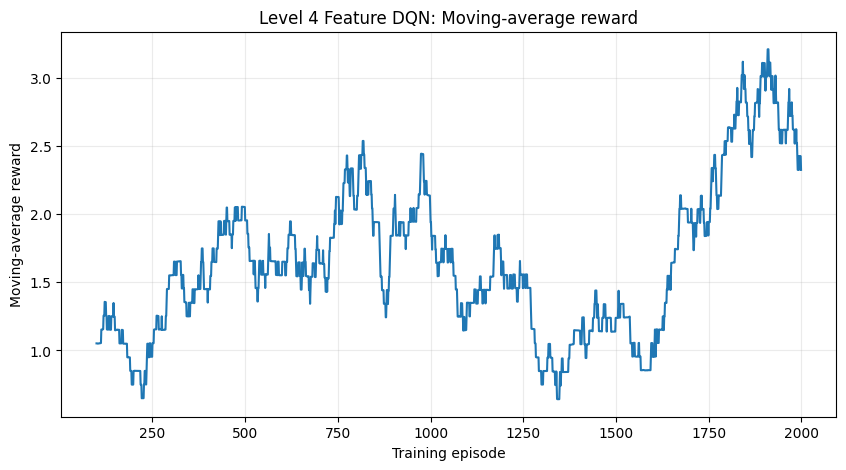

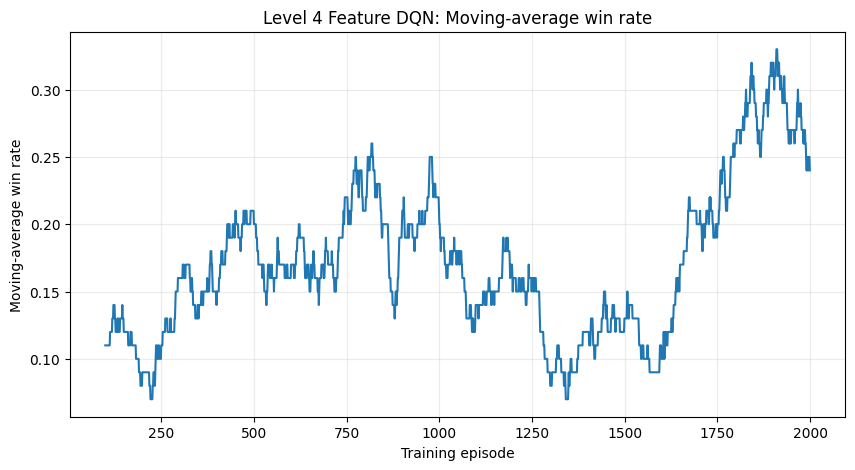

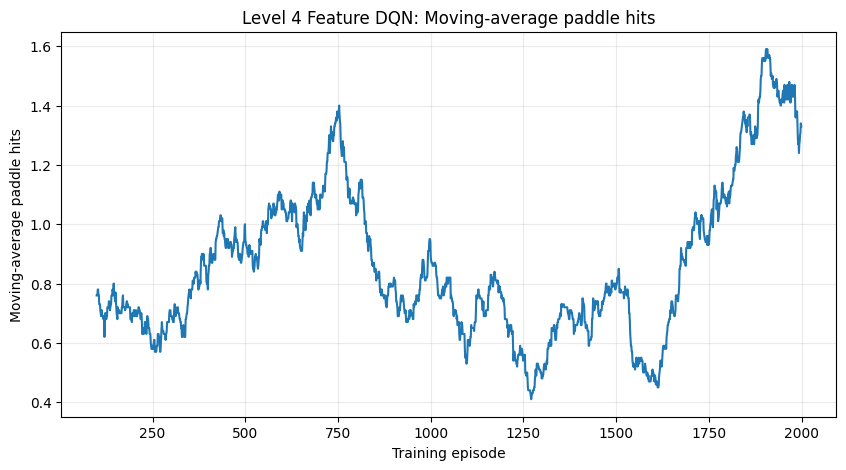

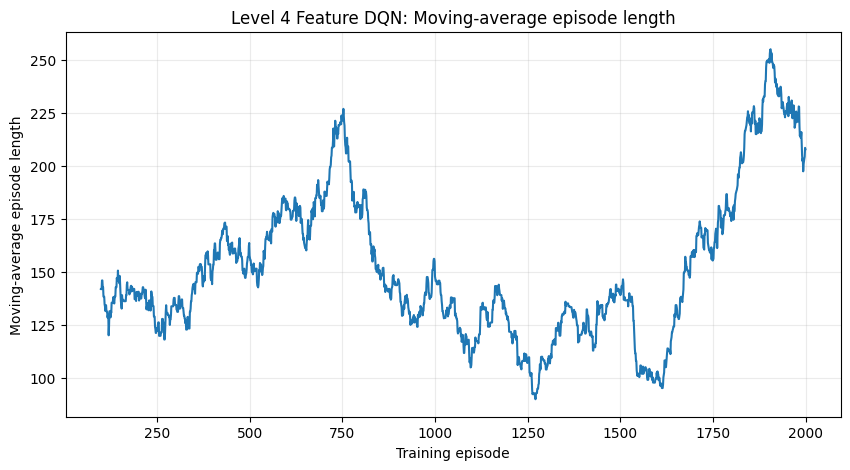

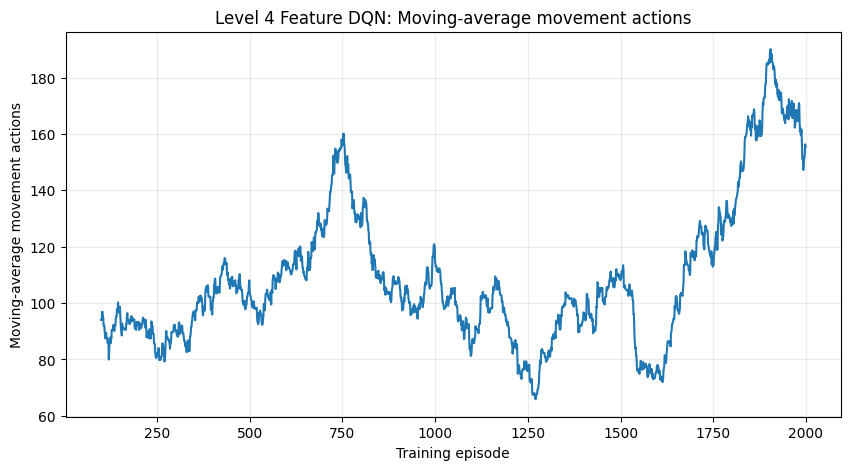

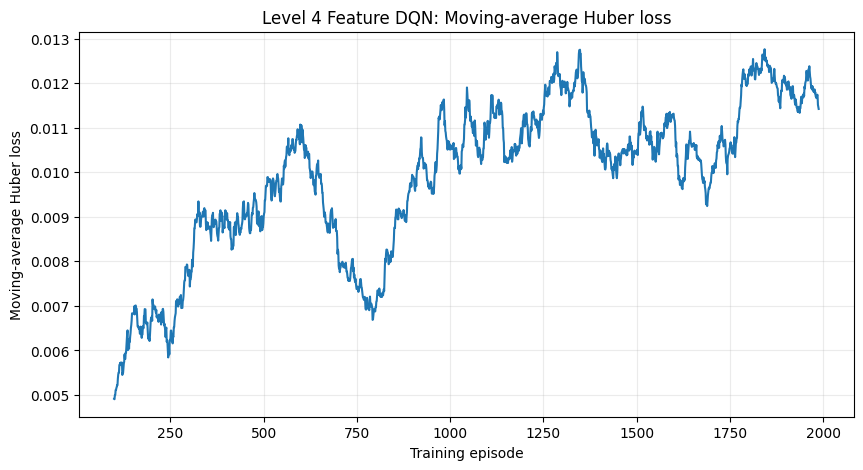

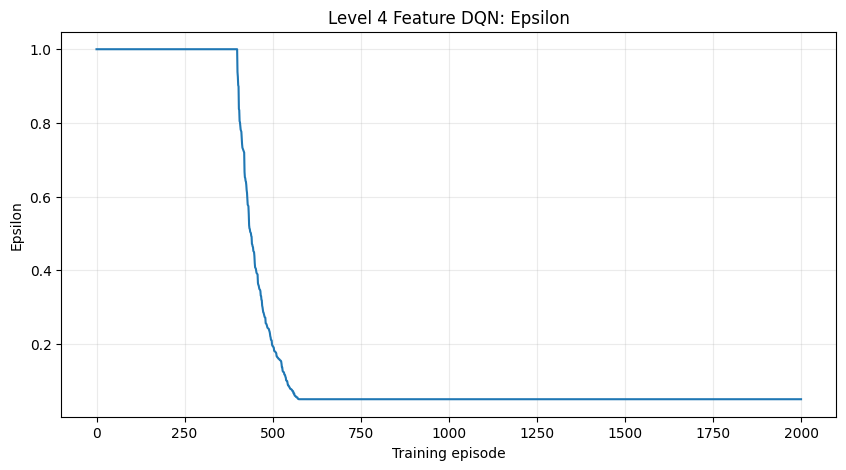

In [16]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)

    if len(values) < window:
        return values

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


def plot_history(
    history,
    metric,
    ylabel,
    window=100,
    ignore_nan=False,
):
    values = np.asarray(history[metric], dtype=float)

    if ignore_nan:
        valid = np.isfinite(values)
        values = values[valid]

    smoothed = moving_average(values, window)

    start = window - 1 if len(values) >= window else 0
    x = np.arange(start, start + len(smoothed))

    plt.figure(figsize=(10, 5))
    plt.plot(x, smoothed)
    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(f"Level 4 Feature DQN: {ylabel}")
    plt.grid(alpha=0.25)
    plt.show()


plot_history(
    history,
    "rewards",
    "Moving-average reward",
)

plot_history(
    history,
    "wins",
    "Moving-average win rate",
)

plot_history(
    history,
    "hits",
    "Moving-average paddle hits",
)

plot_history(
    history,
    "steps",
    "Moving-average episode length",
)

plot_history(
    history,
    "movement_actions",
    "Moving-average movement actions",
)

plot_history(
    history,
    "losses",
    "Moving-average Huber loss",
    ignore_nan=True,
)

plot_history(
    history,
    "epsilon",
    "Epsilon",
    window=1,
)


## Evaluation on unseen seeds


In [17]:
def evaluate_feature_dqn(
    agent,
    opponent: str = "weak",
    n_episodes: int = 200,
    seed: int = 10_000,
    max_seconds: int = 60,
    render_scale: int = 2,
):
    rewards = []
    wins = []
    hits = []
    steps = []
    movement_counts = []
    stay_counts = []
    misses = []
    timeouts = []

    agent.policy_net.eval()

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(
            level=4,
            opponent=opponent,
            max_seconds=max_seconds,
            render_scale=render_scale,
        )

        observation, info = env.reset(
            seed=seed + episode_idx
        )

        agent.reset()

        terminated = False
        truncated = False
        total_reward = 0.0
        movement_count = 0
        stay_count = 0

        while not (terminated or truncated):
            action = agent.select_action(
                observation,
                info=info,
                training=False,
            )

            if action in (ACTION_UP, ACTION_DOWN):
                movement_count += 1
            else:
                stay_count += 1

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            total_reward += float(reward)

        rewards.append(total_reward)
        wins.append(
            float(info.get("winner") == "left")
        )
        hits.append(
            int(info.get("left_hits", 0))
        )
        steps.append(
            int(info.get("steps", 0))
        )
        movement_counts.append(movement_count)
        stay_counts.append(stay_count)
        misses.append(
            float(info.get("done_reason") == "right_scored")
        )
        timeouts.append(
            float(info.get("done_reason") == "timeout")
        )

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "win_rate": float(np.mean(wins)),
        "mean_hits": float(np.mean(hits)),
        "std_hits": float(np.std(hits)),
        "max_hits": int(np.max(hits)),
        "mean_steps": float(np.mean(steps)),
        "mean_movement_actions": float(
            np.mean(movement_counts)
        ),
        "mean_stay_actions": float(
            np.mean(stay_counts)
        ),
        "miss_rate": float(np.mean(misses)),
        "timeout_rate": float(np.mean(timeouts)),
    }


N_EVAL_EPISODES = 200
EVAL_SEED = 10_000

evaluation_result = evaluate_feature_dqn(
    agent,
    opponent=TRAIN_OPPONENT,
    n_episodes=N_EVAL_EPISODES,
    seed=EVAL_SEED,
)

print("===== FEATURE DQN EVALUATION =====")
for key, value in evaluation_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


===== FEATURE DQN EVALUATION =====
mean_reward: 1.9836
std_reward: 4.0349
win_rate: 0.2050
mean_hits: 1.0750
std_hits: 1.1530
max_hits: 5
mean_steps: 172.2300
mean_movement_actions: 130.8850
mean_stay_actions: 41.3450
miss_rate: 0.7950
timeout_rate: 0.0000


## Baseline comparison


In [18]:
def evaluate_generic_agent(
    generic_agent,
    opponent: str = "weak",
    n_episodes: int = 200,
    seed: int = 10_000,
    max_seconds: int = 60,
    render_scale: int = 2,
):
    rewards = []
    wins = []
    steps = []

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(
            level=4,
            opponent=opponent,
            max_seconds=max_seconds,
            render_scale=render_scale,
        )

        observation, info = env.reset(
            seed=seed + episode_idx
        )

        generic_agent.reset()

        terminated = False
        truncated = False
        total_reward = 0.0

        while not (terminated or truncated):
            action = generic_agent.select_action(
                observation,
                info=info,
                training=False,
            )

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            total_reward += float(reward)

        rewards.append(total_reward)
        wins.append(
            float(info.get("winner") == "left")
        )
        steps.append(
            int(info.get("steps", 0))
        )

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "win_rate": float(np.mean(wins)),
        "mean_steps": float(np.mean(steps)),
    }


baseline_results = {
    "Feature DQN": {
        key: evaluation_result[key]
        for key in [
            "mean_reward",
            "std_reward",
            "win_rate",
            "mean_steps",
        ]
    },
    "Random Agent": evaluate_generic_agent(
        RandomAgent(seed=101),
        opponent=TRAIN_OPPONENT,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED,
    ),
    "Tracking Agent": evaluate_generic_agent(
        TrackingAgent(seed=202),
        opponent=TRAIN_OPPONENT,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED,
    ),
}

for name, result in baseline_results.items():
    print(f"\n{name}")
    for key, value in result.items():
        print(f"  {key}: {value:.4f}")



Feature DQN
  mean_reward: 1.9836
  std_reward: 4.0349
  win_rate: 0.2050
  mean_steps: 172.2300

Random Agent
  mean_reward: 1.5015
  std_reward: 3.6135
  win_rate: 0.1550
  mean_steps: 141.7500

Tracking Agent
  mean_reward: 7.6266
  std_reward: 4.3166
  win_rate: 0.7550
  mean_steps: 741.7850


## Save and reload the trained model


In [19]:
SAVE_DIR = PROJECT_ROOT / "saved_agents"
SAVE_DIR.mkdir(exist_ok=True)

SAVE_PATH = SAVE_DIR / "feature_dqn_level4.pt"

agent.save(SAVE_PATH)
print("Saved model to:", SAVE_PATH)

reloaded_agent = FeatureDQNAgent.load(
    SAVE_PATH,
    seed=999,
    device=DEVICE,
)

print(
    "Reloaded:",
    reloaded_agent.name,
    "| environment steps:",
    reloaded_agent.environment_steps,
    "| optimization steps:",
    reloaded_agent.optimization_steps,
)


Saved model to: c:\Users\MANAN\Downloads\Project Starter Code_new\saved_agents\feature_dqn_level4.pt
Reloaded: Level 4 Feature DQN | environment steps: 305564 | optimization steps: 75892


## Verify the reloaded model


In [20]:
reloaded_result = evaluate_feature_dqn(
    reloaded_agent,
    opponent=TRAIN_OPPONENT,
    n_episodes=50,
    seed=20_000,
)

print("===== RELOADED MODEL EVALUATION =====")
for key, value in reloaded_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


===== RELOADED MODEL EVALUATION =====
mean_reward: 1.7263
std_reward: 3.8383
win_rate: 0.1800
mean_hits: 1.2000
std_hits: 1.0770
max_hits: 5
mean_steps: 187.6400
mean_movement_actions: 145.6800
mean_stay_actions: 41.9600
miss_rate: 0.8200
timeout_rate: 0.0000


## Replay diagnostics


In [21]:
REPLAY_SEED = 22
REPLAY_SECONDS = 10

episode = record_episode(
    PaddleDuelEnv(
        level=4,
        opponent=TRAIN_OPPONENT,
        max_seconds=REPLAY_SECONDS,
        render_scale=2,
    ),
    agent,
    seed=REPLAY_SEED,
)

action_counts = Counter(episode.actions)
positions = [
    info["left_paddle_y"]
    for info in episode.infos
]
final_info = episode.infos[-1]

print("===== FEATURE DQN REPLAY =====")
print("ACTION COUNTS")
print(f"  UP   : {action_counts[ACTION_UP]}")
print(f"  DOWN : {action_counts[ACTION_DOWN]}")
print(f"  STAY : {action_counts[ACTION_STAY]}")

print("PADDLE MOVEMENT")
print(f"  Initial position : {positions[0]:.1f}")
print(f"  Minimum position : {min(positions):.1f}")
print(f"  Maximum position : {max(positions):.1f}")
print(
    "  Position range   : "
    f"{max(positions) - min(positions):.1f} pixels"
)

print("EPISODE RESULT")
print(f"  Hits       : {final_info.get('left_hits', 0)}")
print(f"  Reward     : {episode.total_reward:.4f}")
print(f"  Steps      : {final_info.get('steps')}")
print(f"  End reason : {final_info.get('done_reason')}")
print(f"  Winner     : {final_info.get('winner')}")


===== FEATURE DQN REPLAY =====
ACTION COUNTS
  UP   : 107
  DOWN : 24
  STAY : 16
PADDLE MOVEMENT
  Initial position : 154.0
  Minimum position : 42.0
  Maximum position : 210.0
  Position range   : 168.0 pixels
EPISODE RESULT
  Hits       : 1
  Reward     : -0.0710
  Steps      : 147
  End reason : right_scored
  Winner     : right


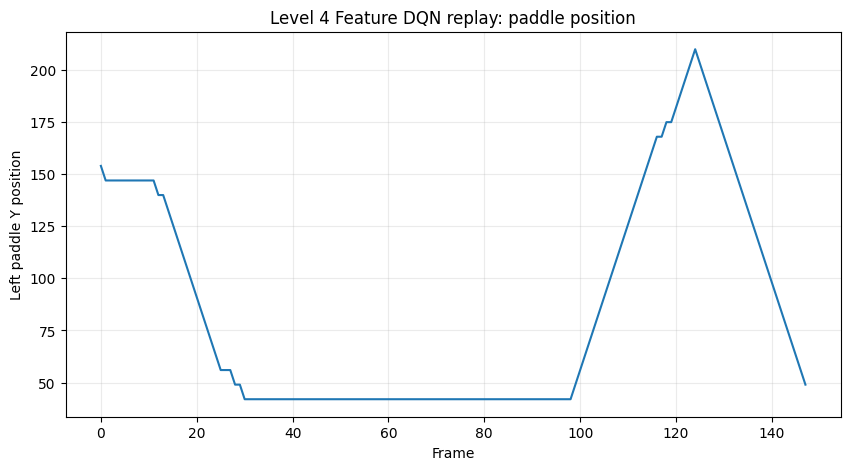

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(positions)
plt.xlabel("Frame")
plt.ylabel("Left paddle Y position")
plt.title("Level 4 Feature DQN replay: paddle position")
plt.grid(alpha=0.25)
plt.show()


## Animate the replay


In [23]:
animate_episode(episode, interval=30)


## Analysis checklist

After running the notebook, check:

1. Does the average loss decrease or stabilize?
2. Does win rate improve after the forced-random phase?
3. Does the feature-based agent outperform the random baseline?
4. How close is it to the tracking baseline?
5. Does it learn to move only when needed?
6. Does it fail when the ball becomes faster?
7. Are the extracted coordinates reliable throughout the replay?
8. Does the reloaded model reproduce similar performance?
9. Does the GPU significantly reduce training time?

Once this feature-based baseline works correctly, the next Level 4 notebook will replace the engineered feature extractor and MLP with a CNN that learns directly from pixel frames.
